In [15]:
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from results_utils import load_results, aggregate_results

sns.set_theme(style="whitegrid")

GRAPHS = ["Dream50", "Dream100"]
GEOM_BASE = "../results/boundary_tracking_dream_geometry"
# Dream geometry runs are stored under the DREAM network's own name, not "Dream50"/"Dream100"
GEOM_FOLDER = {"Dream50": "Size50-Ecoli1", "Dream100": "Size100-Ecoli1"}
PDF_DIR = "PDFs"
os.makedirs(PDF_DIR, exist_ok=True)

# label -> (filename stem, color, drop_first)
# drop_first trims CBO's extra leading Best_Y point (Best_Y only; Per_trial_Y is aligned)
METHODS = {
    "CBO-U": ("cbo_unknown_dr2_results", "red", False),
    "CBO": ("cbo_results", "black", True),
    "Random": ("cbo_results_random", "green", False),
}


def curve(results, experiment, drop_first=False):
    mean, std = aggregate_results(results, experiment)
    if drop_first and experiment == "Best_Y":
        mean, std = mean[1:], std[1:]
    return mean, std


def geom_source(graph):
    return f"{GEOM_BASE}/{GEOM_FOLDER[graph]}", r".*_cbo_unknown_dr2_boundary_EI_200_2_nonlinear.pickle"


def method_regex(stem):
    return rf".*_{stem}_200_2_nonlinear.pickle"


def _plot_on_ax(ax, graph, experiment):
    gbase, gregex = geom_source(graph)
    mean, std = curve(load_results(gbase, gregex), experiment)
    x = range(len(mean))
    ax.fill_between(x, mean - std, mean + std, alpha=0.2, color="purple")
    ax.plot(x, mean, label="CBO-U-Geo", color="purple", linewidth=2)

    for label, (stem, color, drop_first) in METHODS.items():
        mean, std = curve(load_results(f"../results/{graph}", method_regex(stem)),
                          experiment, drop_first)
        x = range(len(mean))
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)
        ax.plot(x, mean, label=label, color=color, linewidth=2)

    ax.set_xlabel("Trial")
    ax.set_ylabel(experiment)
    ax.grid(True)
    ax.legend()


def _show(fig, pdf_name):
    fig.tight_layout()
    fig.savefig(f"{PDF_DIR}/{pdf_name}.pdf", bbox_inches="tight")
    display(fig)
    plt.close(fig)


def plot_experiment(experiment):
    fig, axes = plt.subplots(1, len(GRAPHS), figsize=(14, 5))
    for ax, graph in zip(axes, GRAPHS):
        _plot_on_ax(ax, graph, experiment)
        ax.set_title(graph)
    _show(fig, f"{experiment}")


def plot_graph_stacked(graph):
    fig, axes = plt.subplots(2, 1, figsize=(8, 10))
    for ax, experiment in zip(axes, ["Best_Y", "Per_trial_Y"]):
        _plot_on_ax(ax, graph, experiment)
        ax.set_title(f"{graph} - {experiment}")
    _show(fig, f"{graph}")

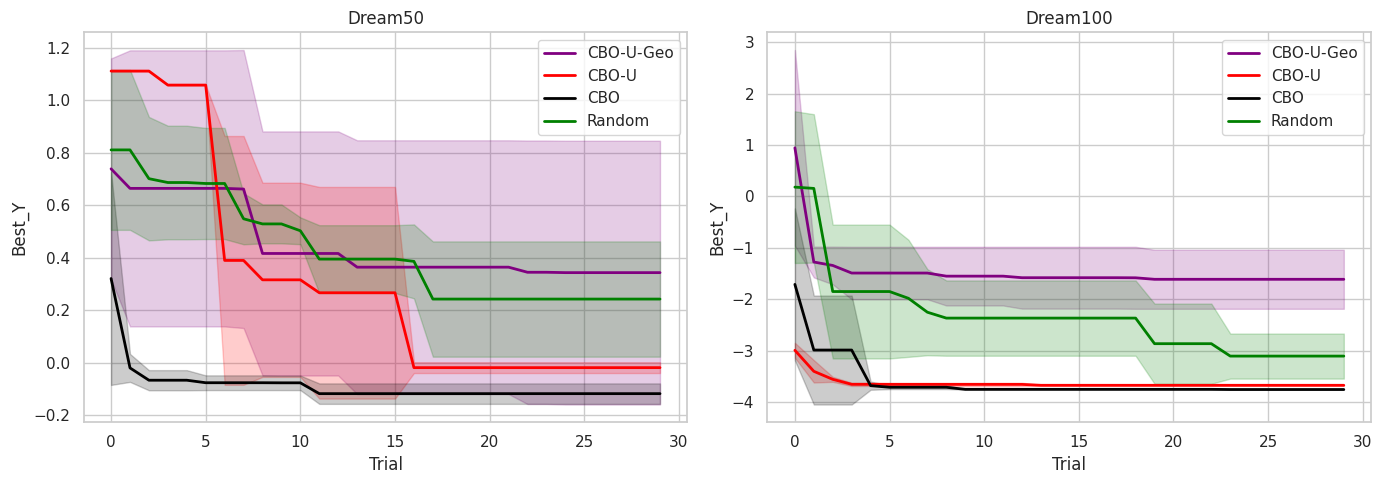

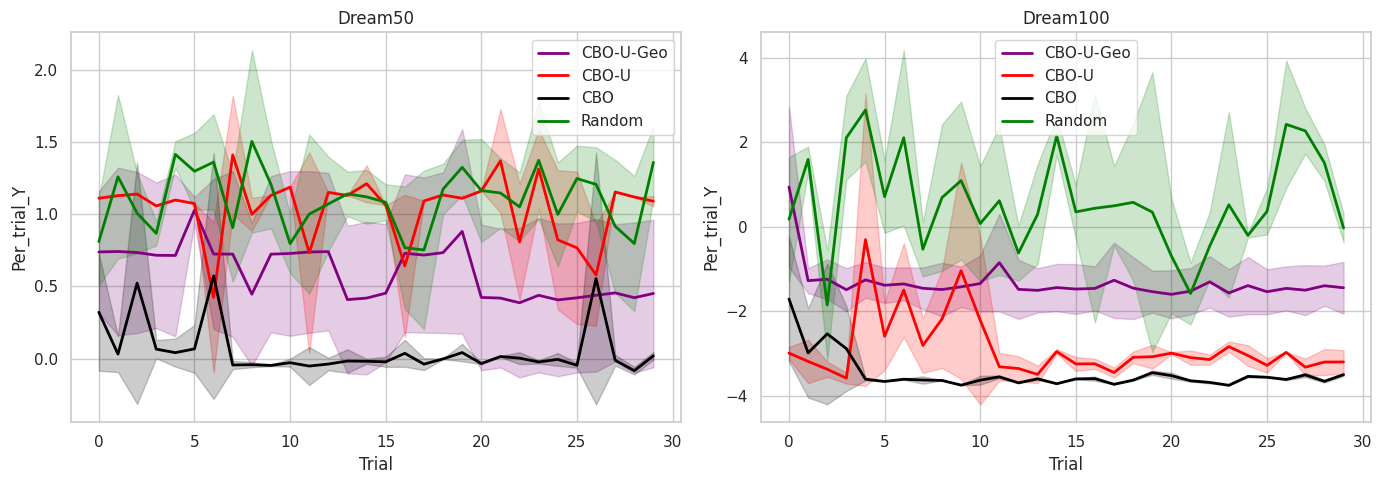

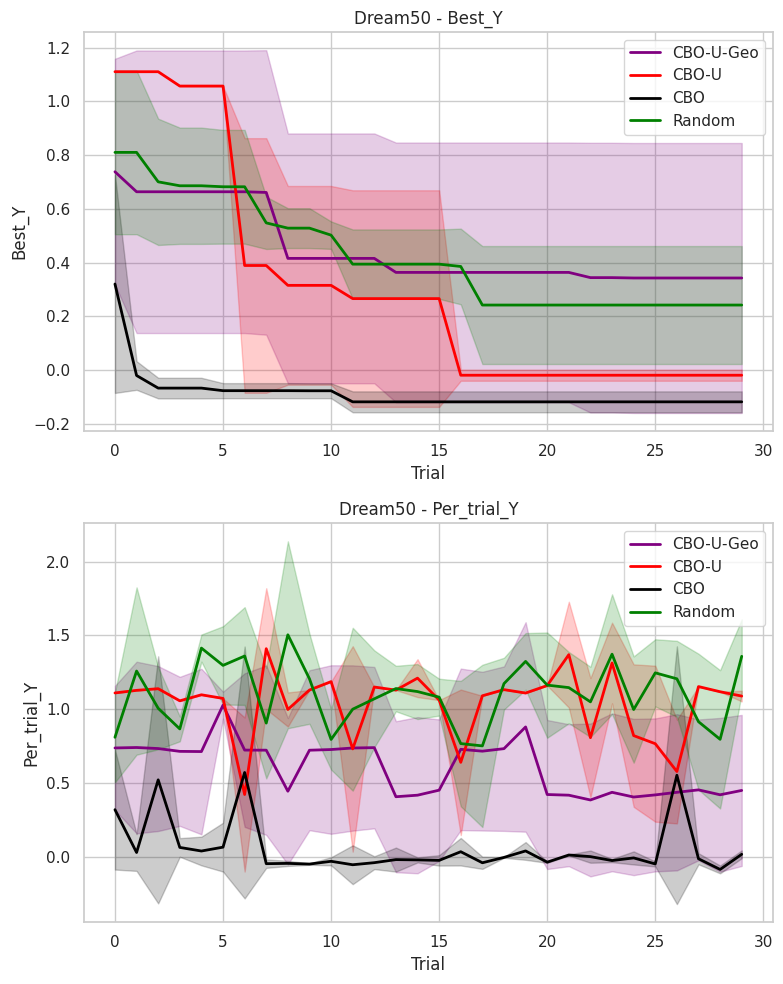

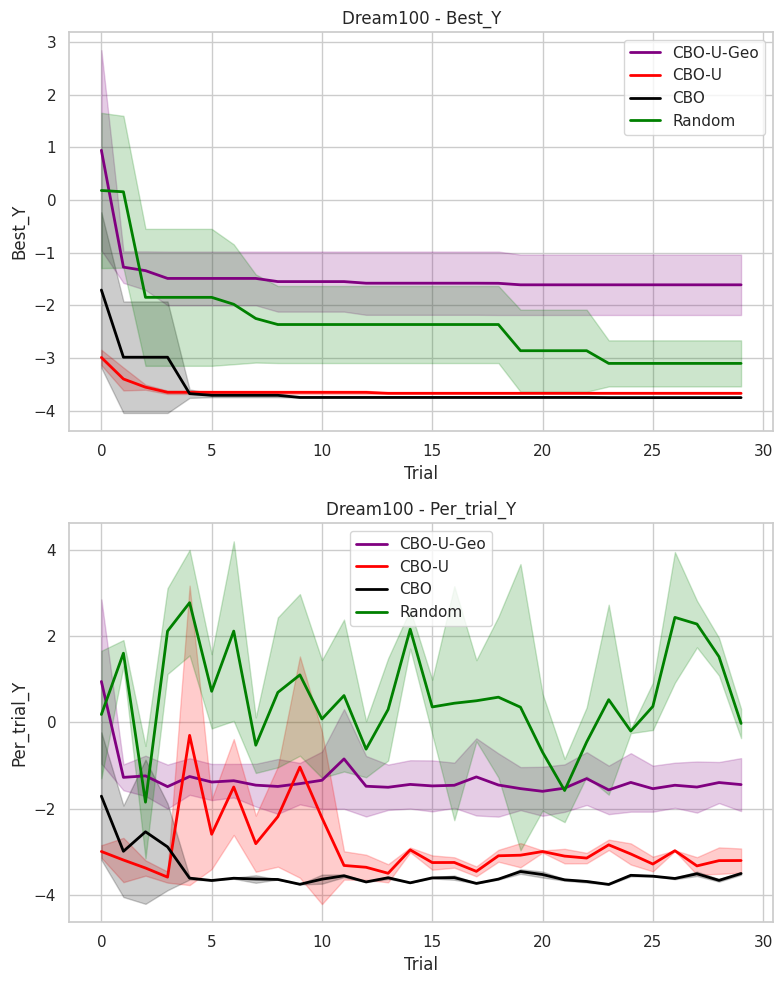

In [16]:
# Comparison figures (Dream50 + Dream100 side by side) -> PDFs/<experiment>.pdf
plot_experiment("Best_Y")
plot_experiment("Per_trial_Y")

# Per-graph PDFs: Best_Y over Per_trial_Y -> PDFs/<graph>.pdf
for graph in GRAPHS:
    plot_graph_stacked(graph)

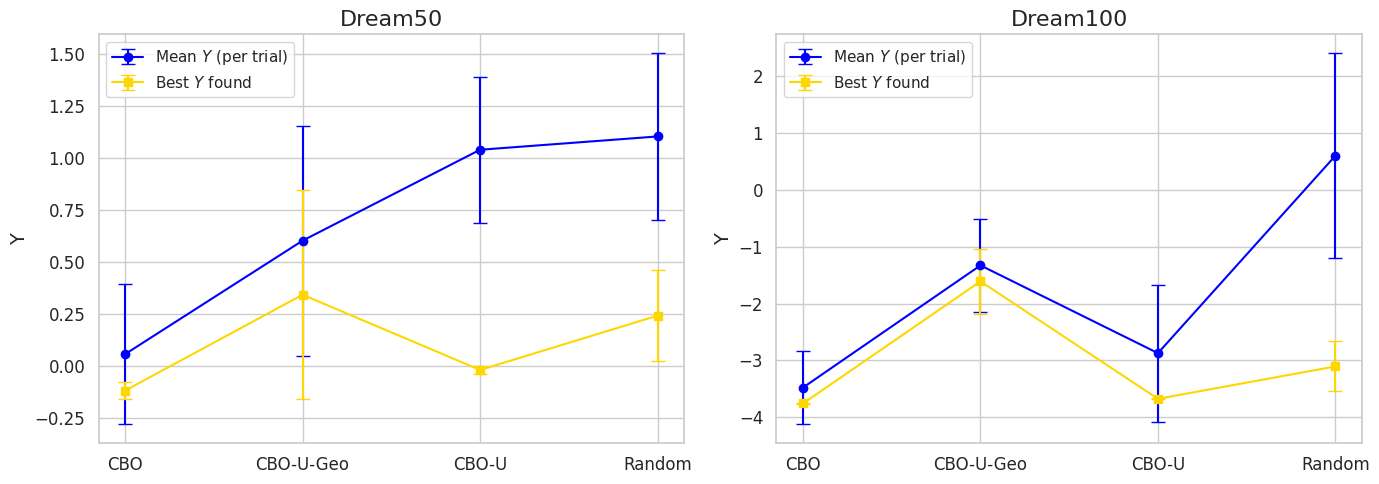

In [17]:
import os

# mean value = mean of Per_trial_Y pooled across all runs/trials (as all_means does)
def mean_value(base, regex):
    if not os.path.isdir(base):
        return np.nan, 0.0
    results = load_results(base, regex)
    if not results:
        return np.nan, 0.0
    pooled = np.hstack([r["Per_trial_Y"] for r in results])
    return pooled.mean(), pooled.std()


# best value = final Best_Y, averaged over the seeds. Note the error bars differ
# in meaning from mean_value's: this one is spread ACROSS seeds, that one is
# spread across pooled trials within runs.
def best_value(base, regex):
    if not os.path.isdir(base):
        return np.nan, 0.0
    results = load_results(base, regex)
    if not results:
        return np.nan, 0.0
    best = np.array([r["Best_Y"][-1] for r in results], dtype=float)
    return best.mean(), best.std()


def summarise():
    method_labels = ["CBO", "CBO-U-Geo", "CBO-U", "Random"]
    fig, axs = plt.subplots(1, len(GRAPHS), figsize=(14, 5))
    for c, graph in enumerate(GRAPHS):
        specs = [
            (f"../results/{graph}", r".*_cbo_results_200_2_nonlinear.pickle"),
            (f"{GEOM_BASE}/{GEOM_FOLDER[graph]}", r".*_cbo_unknown_dr2_boundary_EI_200_2_nonlinear.pickle"),
            (f"../results/{graph}", r".*_cbo_unknown_dr2_results_200_2_nonlinear.pickle"),
            (f"../results/{graph}", r".*_cbo_results_random_200_2_nonlinear.pickle"),
        ]
        means, stds = zip(*[mean_value(b, rx) for b, rx in specs])
        bests, best_stds = zip(*[best_value(b, rx) for b, rx in specs])

        ax = axs[c]
        ax.errorbar(method_labels, means, yerr=stds, marker="o", capsize=5,
                    linestyle="-", color="blue", label="Mean $Y$ (per trial)")
        ax.errorbar(method_labels, bests, yerr=best_stds, marker="s", capsize=5,
                    linestyle="-", color="gold", label="Best $Y$ found")

        ax.tick_params(axis="both", labelsize=12)
        ax.set_title(graph, fontsize=16)
        ax.set_ylabel("Y", fontsize=14)
        ax.legend(fontsize=11)
    _show(fig, "mean_summary")


summarise()